In [543]:
# !pip install tqdm

In [544]:
# !pip install "setuptools<70.0.0"


In [545]:
# %pip install -U ydata-profiling

In [546]:
import pandas as pd

In [547]:
df= pd.read_csv("stock_data.csv")

In [548]:
df.sample(10)

,Date,Open,High,Low,Close,Volume,Ticker
12167,2015-05-13,261.349931,266.357418,255.799933,265.105560,15431501,ICICIBANK.NS
271347,2016-05-18,1092.925747,1101.547225,1089.660082,1095.364136,24168,ABB.NS
355648,2013-03-15,165.822437,169.641378,159.189540,162.164291,34770,COROMANDEL.NS
198695,2021-10-01,5407.870804,5630.798143,5407.870804,5590.388672,195617,TATAELXSI.NS
166024,2024-04-05,65.949997,67.650002,65.199997,66.500000,20745471,IOB.NS
309307,2020-04-28,1344.886873,1346.434738,1279.061325,1294.883545,1206648,COLPAL.NS
295241,2023-03-31,507.756767,507.756767,484.968524,488.702728,753861,TORNTPOWER.NS
264848,2020-01-10,28.779143,29.253850,28.779143,28.838484,23088681,BEL.NS
191422,2022-04-04,3055.386843,3087.927033,3017.995336,3032.000000,349529,MPHASIS.NS
86171,2015-06-16,532.411411,536.235104,522.779592,533.524658,6283177,AXISBANK.NS


In [549]:
df['Date'] = pd.to_datetime(df['Date'])

In [550]:
df = df.sort_values(['Ticker', 'Date'])

In [551]:
price_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df[price_cols] = df[price_cols].astype(float)

In [552]:
df.head(10)

,Date,Open,High,Low,Close,Volume,Ticker
270027,2011-01-03,677.137870,692.240219,677.137870,690.198181,92240.0,ABB.NS
270028,2011-01-04,690.878961,695.218213,681.519759,688.368958,125241.0,ABB.NS
270029,2011-01-05,688.496645,693.261305,673.819702,677.520813,84431.0,ABB.NS
270030,2011-01-06,680.498666,686.582107,670.799117,680.030701,106174.0,ABB.NS
270031,2011-01-07,679.903132,679.903132,660.759322,664.502991,81632.0,ABB.NS
270032,2011-01-10,663.652145,667.906338,627.066212,637.020996,69492.0,ABB.NS
270033,2011-01-11,634.723750,641.487889,616.856219,628.214844,101187.0,ABB.NS
270034,2011-01-12,625.364369,644.805966,617.366509,636.510315,100435.0,ABB.NS
270035,2011-01-13,637.276180,653.782426,635.149084,640.849731,70696.0,ABB.NS
270036,2011-01-14,646.635383,655.058652,625.364477,638.169556,56121.0,ABB.NS


In [553]:
group = df.groupby('Ticker')['Close']

Ticker
ABB.NS           Axes(0.125,0.11;0.775x0.77)
ACC.NS           Axes(0.125,0.11;0.775x0.77)
ADANIPORTS.NS    Axes(0.125,0.11;0.775x0.77)
AMBUJACEM.NS     Axes(0.125,0.11;0.775x0.77)
APOLLOHOSP.NS    Axes(0.125,0.11;0.775x0.77)
                            ...             
UNIONBANK.NS     Axes(0.125,0.11;0.775x0.77)
VEDL.NS          Axes(0.125,0.11;0.775x0.77)
VOLTAS.NS        Axes(0.125,0.11;0.775x0.77)
WIPRO.NS         Axes(0.125,0.11;0.775x0.77)
ZEEL.NS          Axes(0.125,0.11;0.775x0.77)
Name: Close, Length: 100, dtype: object

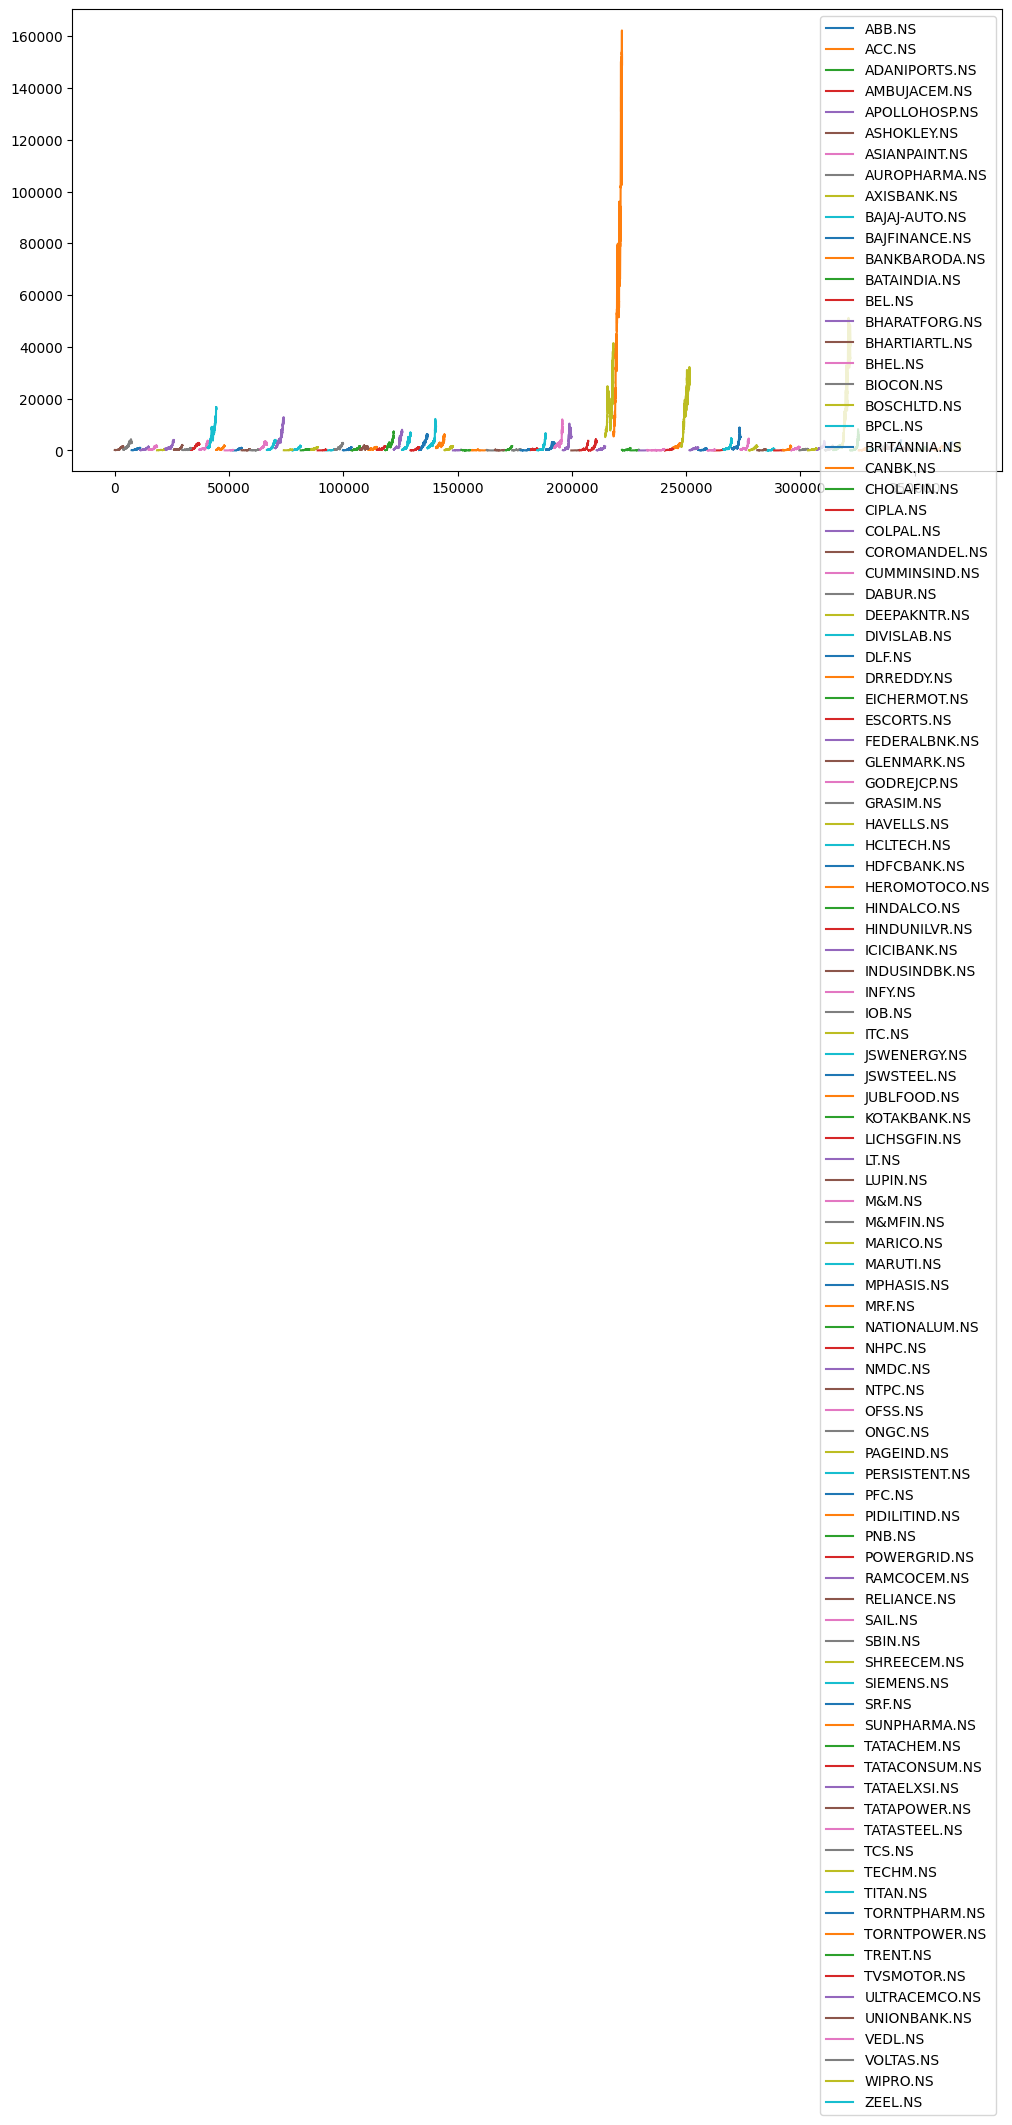

In [554]:
group.plot(legend=True, figsize=(12, 6))

In [555]:
group.describe()

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
ABB.NS,3699.0,1984.182102,1910.770921,386.600708,859.279846,1159.644043,2189.428711,8899.636719
ACC.NS,3699.0,1529.550067,464.400144,761.643677,1204.410645,1422.725342,1851.750000,2761.104492
ADANIPORTS.NS,3699.0,495.736830,394.599521,100.876312,211.700462,347.135956,719.060394,1582.451172
AMBUJACEM.NS,3699.0,274.067347,152.456400,92.916634,172.066963,201.993118,368.483459,692.465088
APOLLOHOSP.NS,3699.0,2486.017379,2176.465018,424.982452,982.939240,1299.213867,4320.496338,8001.377441
...,...,...,...,...,...,...,...,...
UNIONBANK.NS,3699.0,107.742086,54.405222,19.734447,64.133354,112.218559,143.255333,253.287552
VEDL.NS,3699.0,133.015539,118.713403,20.470488,58.279942,83.172012,176.143906,595.602905
VOLTAS.NS,3699.0,599.906354,450.101415,59.447842,222.248848,527.554321,891.512238,1918.490601


In [556]:
future_price = group.shift(-5)

In [557]:
future_price.head()

270027    637.020996
270028    628.214844
270029    636.510315
270030    640.849731
270031    638.169556
Name: Close, dtype: float64

In [558]:

current_price = df['Close']

In [559]:

import numpy as np

current_price = df['Close']

returns = future_price / current_price - 1

df['future_returns_5days'] = returns

def label(x):
    if pd.isna(x):
        return np.nan
    elif x >= 0.66:
        return 1
    elif x <= 0.33:
        return -1
    else:
        return 0
        

df['future_return_rank'] = df.groupby('Date')['future_returns_5days'].rank(pct=True)
df['target'] = df['future_return_rank'].apply(label)

In [560]:
df.head(20)

,Date,Open,High,Low,Close,Volume,Ticker,future_returns_5days,future_return_rank,target
270027,2011-01-03,677.137870,692.240219,677.137870,690.198181,92240.0,ABB.NS,-0.077046,0.36,0.0
270028,2011-01-04,690.878961,695.218213,681.519759,688.368958,125241.0,ABB.NS,-0.087386,0.25,-1.0
270029,2011-01-05,688.496645,693.261305,673.819702,677.520813,84431.0,ABB.NS,-0.060530,0.27,-1.0
270030,2011-01-06,680.498666,686.582107,670.799117,680.030701,106174.0,ABB.NS,-0.057616,0.29,-1.0
270031,2011-01-07,679.903132,679.903132,660.759322,664.502991,81632.0,ABB.NS,-0.039629,0.38,0.0
270032,2011-01-10,663.652145,667.906338,627.066212,637.020996,69492.0,ABB.NS,-0.003139,0.65,0.0
270033,2011-01-11,634.723750,641.487889,616.856219,628.214844,101187.0,ABB.NS,0.016591,0.74,1.0
270034,2011-01-12,625.364369,644.805966,617.366509,636.510315,100435.0,ABB.NS,-0.014837,0.56,0.0
270035,2011-01-13,637.276180,653.782426,635.149084,640.849731,70696.0,ABB.NS,-0.013011,0.44,0.0
270036,2011-01-14,646.635383,655.058652,625.364477,638.169556,56121.0,ABB.NS,-0.007133,0.36,0.0


In [561]:
df['target'].value_counts()

target
 1.0    129289
-1.0    121901
 0.0    118210
Name: count, dtype: int64

In [562]:
df['MA_50'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(50).mean())
df['MA_200'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(200).mean())

In [563]:
df['Dist_to_MA50'] = df['Close'] / df['MA_50'] - 1
df['Dist_to_MA200'] = df['Close'] / df['MA_200'] - 1

In [564]:
df.head(200)

,Date,Open,High,Low,Close,Volume,Ticker,future_returns_5days,future_return_rank,target,MA_50,MA_200,Dist_to_MA50,Dist_to_MA200
270027,2011-01-03,677.137870,692.240219,677.137870,690.198181,92240.0,ABB.NS,-0.077046,0.36,0.0,NaN,NaN,NaN,NaN
270028,2011-01-04,690.878961,695.218213,681.519759,688.368958,125241.0,ABB.NS,-0.087386,0.25,-1.0,NaN,NaN,NaN,NaN
270029,2011-01-05,688.496645,693.261305,673.819702,677.520813,84431.0,ABB.NS,-0.060530,0.27,-1.0,NaN,NaN,NaN,NaN
270030,2011-01-06,680.498666,686.582107,670.799117,680.030701,106174.0,ABB.NS,-0.057616,0.29,-1.0,NaN,NaN,NaN,NaN
270031,2011-01-07,679.903132,679.903132,660.759322,664.502991,81632.0,ABB.NS,-0.039629,0.38,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270222,2011-10-14,585.906542,592.389595,584.754967,587.484680,71089.0,ABB.NS,0.012052,0.84,1.0,670.154771,NaN,-0.123360,NaN
270223,2011-10-17,567.353127,592.858837,567.353127,578.698486,84656.0,ABB.NS,0.001769,0.57,0.0,666.809169,NaN,-0.132138,NaN
270224,2011-10-18,575.925918,575.925918,563.983442,567.054382,173773.0,ABB.NS,0.061151,0.84,1.0,663.564225,NaN,-0.145442,NaN
270225,2011-10-19,571.916826,612.478565,570.040126,608.682556,469570.0,ABB.NS,0.001051,0.24,-1.0,661.200468,NaN,-0.079428,NaN


In [565]:
df=df.dropna()

In [566]:
df.sample(10)

,Date,Open,High,Low,Close,Volume,Ticker,future_returns_5days,future_return_rank,target,MA_50,MA_200,Dist_to_MA50,Dist_to_MA200
352450,2015-04-06,134.401539,134.690380,131.376334,132.987747,549282.0,TATACHEM.NS,0.033836,0.59,0.0,136.460514,121.663425,-0.025449,0.093079
317763,2024-08-05,1567.705786,1591.254405,1524.746868,1534.304199,528741.0,BATAINDIA.NS,-0.088877,0.02,-1.0,1457.892827,1457.229705,0.052412,0.052891
191300,2021-10-06,2895.478028,2897.034052,2820.145945,2848.155273,598884.0,MPHASIS.NS,0.006010,0.18,-1.0,2637.513437,1863.324467,0.079864,0.528534
278789,2016-07-20,337.756286,344.870893,337.007393,342.858215,2477492.0,HAVELLS.NS,0.028396,0.81,1.0,336.422307,285.937397,0.019130,0.199067
116828,2019-10-15,415.517831,423.544880,411.126569,421.703369,3153015.0,CIPLA.NS,0.017243,0.32,-1.0,439.310911,489.814389,-0.040080,-0.139055
103985,2012-09-03,104.892698,109.282683,104.892698,108.582153,622511.0,ADANIPORTS.NS,-0.030538,0.04,-1.0,110.575959,118.013436,-0.018031,-0.079917
287458,2021-09-14,299.961562,300.010284,291.481727,300.010284,2077692.0,JSWENERGY.NS,0.098116,0.98,1.0,223.672097,124.383643,0.341295,1.411975
142755,2019-12-04,1924.719499,1955.538871,1918.356789,1939.830933,457308.0,HEROMOTOCO.NS,-0.058508,0.11,-1.0,2080.838540,2070.361547,-0.067765,-0.063047
173381,2024-02-05,1157.655441,1167.368987,1126.472419,1132.101318,1564033.0,CHOLAFIN.NS,-0.029534,0.25,-1.0,1202.640684,1122.420994,-0.058654,0.008625
60315,2015-08-06,103.646637,104.602781,103.053820,103.627510,3982426.0,ONGC.NS,-0.004429,0.79,1.0,114.054913,125.834906,-0.091424,-0.176480


In [567]:
df['target'].value_counts()

target
 1.0    122324
-1.0    115334
 0.0    111842
Name: count, dtype: int64

In [568]:
df = df.reset_index(drop=True)

In [569]:
df.head()


,Date,Open,High,Low,Close,Volume,Ticker,future_returns_5days,future_return_rank,target,MA_50,MA_200,Dist_to_MA50,Dist_to_MA200
0,2011-10-20,597.166620,603.265778,570.082775,597.678406,136221.0,ABB.NS,0.013273,0.27,-1.0,659.125887,675.575904,-0.093226,-0.115305
1,2011-10-21,609.791526,609.791526,589.105455,594.564880,120398.0,ABB.NS,-0.013128,0.08,-1.0,657.248359,675.097738,-0.095373,-0.119291
2,2011-10-24,597.081283,603.948232,578.357190,579.722046,85602.0,ABB.NS,-0.009859,0.12,-1.0,655.099565,674.554503,-0.115063,-0.140585
3,2011-10-25,587.655275,609.663593,577.504216,601.730347,128655.0,ABB.NS,-0.046144,0.02,-1.0,653.529130,674.175551,-0.079260,-0.107457
4,2011-10-28,609.919509,646.002842,605.654325,609.322388,75687.0,ABB.NS,-0.051799,0.04,-1.0,652.078972,673.822009,-0.065570,-0.095722


In [570]:
df['Golden_Cross'] = (df['MA_50'] > df['MA_200']).astype(int)

In [571]:
df.sample(10)

,Date,Open,High,Low,Close,Volume,Ticker,future_returns_5days,future_return_rank,target,MA_50,MA_200,Dist_to_MA50,Dist_to_MA200,Golden_Cross
22802,2019-04-03,1436.356973,1444.477029,1409.683458,1414.026733,1606692.0,ASIANPAINT.NS,-0.058594,0.03,-1.0,1346.863281,1275.258218,0.049867,0.108816,1
243443,2021-02-05,810.689330,825.037814,793.949432,813.319885,379726.0,PERSISTENT.NS,0.063757,0.93,1.0,691.941327,493.660335,0.175417,0.647529,1
277416,2017-02-21,681.833499,685.555689,676.111230,678.833496,475741.0,SIEMENS.NS,-0.004051,0.46,0.0,639.080302,656.957609,0.062204,0.033299,0
332700,2014-07-17,165.629132,166.608218,163.059030,165.425156,3031342.0,UNIONBANK.NS,-0.020715,0.24,-1.0,174.286935,117.480921,-0.050846,0.408102,1
104643,2025-02-20,5888.188778,5960.808308,5865.591477,5951.201660,292029.0,DIVISLAB.NS,-0.083310,0.19,-1.0,5856.096895,5271.010858,0.016240,0.129044,1
309541,2019-11-15,599.652275,603.526886,592.496152,594.591614,1787358.0,TECHM.NS,0.002992,0.52,0.0,573.023539,578.092170,0.037639,0.028541,0
112068,2012-09-24,209.948333,210.482083,202.535226,206.339859,103540.0,EICHERMOT.NS,-0.001194,0.22,-1.0,190.470992,175.740581,0.083314,0.174116,1
339455,2013-08-02,70.205948,70.437804,66.032542,69.185783,2167171.0,VOLTAS.NS,0.019437,0.57,0.0,74.582772,84.215592,-0.072362,-0.178468,0
224786,2016-04-27,13.892653,13.927630,13.731762,13.815705,5468862.0,NMDC.NS,-0.055696,0.19,-1.0,12.651278,11.692615,0.092040,0.181575,1
46680,2016-11-18,33.333090,33.632699,33.164798,33.349663,8050416.0,BEL.NS,-0.002408,0.38,0.0,32.283088,30.588601,0.033038,0.090264,1


In [572]:
df['ma_ratio'] = df['MA_50'] / df['MA_200']

In [573]:
df

,Date,Open,High,Low,Close,Volume,Ticker,future_returns_5days,future_return_rank,target,MA_50,MA_200,Dist_to_MA50,Dist_to_MA200,Golden_Cross,ma_ratio
0,2011-10-20,597.166620,603.265778,570.082775,597.678406,136221.0,ABB.NS,0.013273,0.27,-1.0,659.125887,675.575904,-0.093226,-0.115305,0,0.975650
1,2011-10-21,609.791526,609.791526,589.105455,594.564880,120398.0,ABB.NS,-0.013128,0.08,-1.0,657.248359,675.097738,-0.095373,-0.119291,0,0.973560
2,2011-10-24,597.081283,603.948232,578.357190,579.722046,85602.0,ABB.NS,-0.009859,0.12,-1.0,655.099565,674.554503,-0.115063,-0.140585,0,0.971159
3,2011-10-25,587.655275,609.663593,577.504216,601.730347,128655.0,ABB.NS,-0.046144,0.02,-1.0,653.529130,674.175551,-0.079260,-0.107457,0,0.969375
4,2011-10-28,609.919509,646.002842,605.654325,609.322388,75687.0,ABB.NS,-0.051799,0.04,-1.0,652.078972,673.822009,-0.065570,-0.095722,0,0.967732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349495,2025-12-17,92.900002,94.199997,92.410004,92.589996,6563617.0,ZEEL.NS,-0.008424,0.09,-1.0,100.950800,113.159163,-0.082821,-0.181772,0,0.892113
349496,2025-12-18,92.849998,93.180000,89.820000,90.480003,9312385.0,ZEEL.NS,0.008068,0.43,0.0,100.512600,113.122968,-0.099814,-0.200162,0,0.888525
349497,2025-12-19,90.980003,92.349998,90.260002,90.529999,9262270.0,ZEEL.NS,0.002320,0.56,0.0,100.140200,113.099853,-0.095967,-0.199557,0,0.885414
349498,2025-12-22,91.180000,93.169998,91.120003,91.919998,7192902.0,ZEEL.NS,-0.024369,0.20,-1.0,99.781600,113.103571,-0.078788,-0.187294,0,0.882214


In [574]:
df['volatility_5'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(5).std())
df['volatility_20'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(20).std())

In [575]:
df

,Date,Open,High,Low,Close,Volume,Ticker,future_returns_5days,future_return_rank,target,MA_50,MA_200,Dist_to_MA50,Dist_to_MA200,Golden_Cross,ma_ratio,volatility_5,volatility_20
0,2011-10-20,597.166620,603.265778,570.082775,597.678406,136221.0,ABB.NS,0.013273,0.27,-1.0,659.125887,675.575904,-0.093226,-0.115305,0,0.975650,NaN,NaN
1,2011-10-21,609.791526,609.791526,589.105455,594.564880,120398.0,ABB.NS,-0.013128,0.08,-1.0,657.248359,675.097738,-0.095373,-0.119291,0,0.973560,NaN,NaN
2,2011-10-24,597.081283,603.948232,578.357190,579.722046,85602.0,ABB.NS,-0.009859,0.12,-1.0,655.099565,674.554503,-0.115063,-0.140585,0,0.971159,NaN,NaN
3,2011-10-25,587.655275,609.663593,577.504216,601.730347,128655.0,ABB.NS,-0.046144,0.02,-1.0,653.529130,674.175551,-0.079260,-0.107457,0,0.969375,NaN,NaN
4,2011-10-28,609.919509,646.002842,605.654325,609.322388,75687.0,ABB.NS,-0.051799,0.04,-1.0,652.078972,673.822009,-0.065570,-0.095722,0,0.967732,10.935602,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349495,2025-12-17,92.900002,94.199997,92.410004,92.589996,6563617.0,ZEEL.NS,-0.008424,0.09,-1.0,100.950800,113.159163,-0.082821,-0.181772,0,0.892113,0.700371,2.795128
349496,2025-12-18,92.849998,93.180000,89.820000,90.480003,9312385.0,ZEEL.NS,0.008068,0.43,0.0,100.512600,113.122968,-0.099814,-0.200162,0,0.888525,1.442107,3.053945
349497,2025-12-19,90.980003,92.349998,90.260002,90.529999,9262270.0,ZEEL.NS,0.002320,0.56,0.0,100.140200,113.099853,-0.095967,-0.199557,0,0.885414,1.468372,3.250974
349498,2025-12-22,91.180000,93.169998,91.120003,91.919998,7192902.0,ZEEL.NS,-0.024369,0.20,-1.0,99.781600,113.103571,-0.078788,-0.187294,0,0.882214,1.089288,3.294822


In [576]:
df=df.dropna()

In [577]:
df=df.reset_index(drop=True)

In [578]:
df.head(14)

,Date,Open,High,Low,Close,Volume,Ticker,future_returns_5days,future_return_rank,target,MA_50,MA_200,Dist_to_MA50,Dist_to_MA200,Golden_Cross,ma_ratio,volatility_5,volatility_20
0,2011-11-22,522.184908,527.601666,516.085693,518.516846,51818.0,ABB.NS,-0.013079,0.23,-1.0,615.391670,668.950707,-0.157420,-0.224880,0,0.919936,11.003867,30.278155
1,2011-11-23,512.758891,519.327223,494.759864,499.323608,75192.0,ABB.NS,0.019305,0.43,0.0,610.738368,668.331776,-0.182426,-0.252881,0,0.913825,12.240162,34.124011
2,2011-11-24,499.323625,507.598043,487.253199,499.195679,102994.0,ABB.NS,0.032638,0.56,0.0,606.009146,667.783463,-0.176257,-0.252459,0,0.907493,13.188901,37.044058
3,2011-11-25,499.025037,528.625314,489.001867,522.227539,121554.0,ABB.NS,0.010699,0.19,-1.0,601.857428,667.417951,-0.132307,-0.217540,0,0.901770,11.360037,38.074097
4,2011-11-28,525.895621,534.681881,518.730110,522.568787,100185.0,ABB.NS,0.039258,0.62,0.0,597.791870,667.024579,-0.125835,-0.216567,0,0.896207,12.070015,37.875917
5,2011-11-29,520.350875,528.881184,508.408396,511.735229,128355.0,ABB.NS,0.070095,0.79,1.0,593.289556,666.642978,-0.137461,-0.232370,0,0.889966,11.577075,37.246320
6,2011-11-30,507.555366,516.085734,494.759873,508.962891,109531.0,ABB.NS,0.028827,0.65,0.0,588.620049,666.359614,-0.135329,-0.236204,0,0.883337,9.812583,36.387123
7,2011-12-01,527.601680,538.264581,509.261425,515.488586,107142.0,ABB.NS,0.002068,0.66,1.0,584.156122,666.196726,-0.117550,-0.226222,0,0.876852,6.117774,35.945970
8,2011-12-02,513.142689,533.146359,511.905836,527.814880,65248.0,ABB.NS,-0.053899,0.45,0.0,580.502574,666.211185,-0.090762,-0.207736,0,0.871349,7.779414,35.470971
9,2011-12-05,528.454466,544.662122,527.132279,543.083984,114142.0,ABB.NS,-0.063064,0.35,0.0,577.392405,666.174362,-0.059420,-0.184772,0,0.866729,14.092362,34.705929


In [579]:
group = df.groupby('Ticker')['Close']

delta = group.diff()

gain = delta.clip(lower=0) # Only positive changes (gains)
loss = -delta.clip(upper=0) # Only negative changes (losses), negated to make them positive

avg_gain = gain.groupby(df['Ticker']).transform(lambda x: x.rolling(14).mean())
avg_loss = loss.groupby(df['Ticker']).transform(lambda x: x.rolling(14).mean())

rs = avg_gain / avg_loss
df['RSI_14'] = 100 - (100 / (1 + rs))

In [580]:
df

,Date,Open,High,Low,Close,Volume,Ticker,future_returns_5days,future_return_rank,target,MA_50,MA_200,Dist_to_MA50,Dist_to_MA200,Golden_Cross,ma_ratio,volatility_5,volatility_20,RSI_14
0,2011-11-22,522.184908,527.601666,516.085693,518.516846,51818.0,ABB.NS,-0.013079,0.23,-1.0,615.391670,668.950707,-0.157420,-0.224880,0,0.919936,11.003867,30.278155,NaN
1,2011-11-23,512.758891,519.327223,494.759864,499.323608,75192.0,ABB.NS,0.019305,0.43,0.0,610.738368,668.331776,-0.182426,-0.252881,0,0.913825,12.240162,34.124011,NaN
2,2011-11-24,499.323625,507.598043,487.253199,499.195679,102994.0,ABB.NS,0.032638,0.56,0.0,606.009146,667.783463,-0.176257,-0.252459,0,0.907493,13.188901,37.044058,NaN
3,2011-11-25,499.025037,528.625314,489.001867,522.227539,121554.0,ABB.NS,0.010699,0.19,-1.0,601.857428,667.417951,-0.132307,-0.217540,0,0.901770,11.360037,38.074097,NaN
4,2011-11-28,525.895621,534.681881,518.730110,522.568787,100185.0,ABB.NS,0.039258,0.62,0.0,597.791870,667.024579,-0.125835,-0.216567,0,0.896207,12.070015,37.875917,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347595,2025-12-17,92.900002,94.199997,92.410004,92.589996,6563617.0,ZEEL.NS,-0.008424,0.09,-1.0,100.950800,113.159163,-0.082821,-0.181772,0,0.892113,0.700371,2.795128,35.465115
347596,2025-12-18,92.849998,93.180000,89.820000,90.480003,9312385.0,ZEEL.NS,0.008068,0.43,0.0,100.512600,113.122968,-0.099814,-0.200162,0,0.888525,1.442107,3.053945,18.866837
347597,2025-12-19,90.980003,92.349998,90.260002,90.529999,9262270.0,ZEEL.NS,0.002320,0.56,0.0,100.140200,113.099853,-0.095967,-0.199557,0,0.885414,1.468372,3.250974,20.672741
347598,2025-12-22,91.180000,93.169998,91.120003,91.919998,7192902.0,ZEEL.NS,-0.024369,0.20,-1.0,99.781600,113.103571,-0.078788,-0.187294,0,0.882214,1.089288,3.294822,30.833844


In [581]:
df=df.dropna()

In [582]:
df=df.reset_index(drop=True)

In [583]:
df.head(20)

,Date,Open,High,Low,Close,Volume,Ticker,future_returns_5days,future_return_rank,target,MA_50,MA_200,Dist_to_MA50,Dist_to_MA200,Golden_Cross,ma_ratio,volatility_5,volatility_20,RSI_14
0,2011-12-13,494.930355,512.673427,491.646189,508.834808,71555.0,ABB.NS,-0.086756,0.35,0.0,562.890820,665.133630,-0.096033,-0.234989,0,0.846282,18.264377,17.930727,46.828691
1,2011-12-14,509.943752,511.393887,500.730931,504.612274,37645.0,ABB.NS,-0.046150,0.35,0.0,560.153433,664.830001,-0.099153,-0.240991,0,0.842551,9.624682,14.641401,51.920640
2,2011-12-15,503.290251,503.290251,486.314852,490.665314,70233.0,ABB.NS,-0.006606,0.65,0.0,557.375103,664.462380,-0.119686,-0.261560,0,0.838836,9.755244,14.676010,47.184676
3,2011-12-16,490.494651,499.878032,474.798832,479.874390,54732.0,ABB.NS,0.050662,0.92,1.0,554.980637,664.038466,-0.135331,-0.277339,0,0.835766,11.581026,16.504533,34.793266
4,2011-12-19,476.504894,476.504894,466.268472,469.851227,41462.0,ABB.NS,0.078431,0.93,1.0,552.551194,663.430428,-0.149669,-0.291785,0,0.832870,16.388000,18.878933,32.302392
5,2011-12-20,473.348622,473.348622,461.491451,464.690338,33505.0,ABB.NS,0.077650,0.91,1.0,550.218998,662.904005,-0.155445,-0.299008,0,0.830013,16.109928,21.468969,33.581407
6,2011-12-21,468.870232,490.068115,466.183158,481.324524,45168.0,ABB.NS,0.029951,0.83,1.0,548.242518,662.418849,-0.122059,-0.273383,0,0.827637,10.197327,22.175804,41.205197
7,2011-12-22,482.134926,489.641607,473.561892,487.423737,58552.0,ABB.NS,0.007525,0.75,1.0,546.550096,662.019919,-0.108181,-0.263733,0,0.825580,9.186629,22.545517,41.045180
8,2011-12-23,505.849361,525.511806,499.878092,504.185944,293775.0,ABB.NS,-0.013112,0.40,0.0,545.273961,661.629075,-0.075353,-0.237963,0,0.824138,15.556606,22.490584,42.668123
9,2011-12-26,509.858428,510.882056,499.024915,506.702209,87296.0,ABB.NS,-0.020707,0.55,0.0,544.063503,661.233371,-0.068671,-0.233701,0,0.822801,17.293407,22.185960,37.740797


In [584]:
df['Daily_Return'] = df.groupby('Ticker')['Close'].pct_change()

In [585]:
# Advanced Momentum & Volume
df['Momentum_Acceleration'] = df.groupby('Ticker')['Daily_Return'].diff()
df['VPT'] = df['Daily_Return'] * df['Volume']
df['VPT_MA10'] = df.groupby('Ticker')['VPT'].transform(lambda x: x.rolling(10).mean())
df=df.dropna()
df=df.reset_index(drop=True)

In [586]:
df.head(10)

,Date,Open,High,Low,Close,Volume,Ticker,future_returns_5days,future_return_rank,target,...,Dist_to_MA200,Golden_Cross,ma_ratio,volatility_5,volatility_20,RSI_14,Daily_Return,Momentum_Acceleration,VPT,VPT_MA10
0,2011-12-27,505.806662,506.275836,499.878061,500.773743,36526.0,ABB.NS,0.010987,0.48,0.0,...,-0.241979,0,0.821635,11.104322,21.849025,34.367831,-0.011700,-0.016691,-427.357872,777.856728
1,2011-12-28,501.200271,501.200271,490.494701,495.740845,35436.0,ABB.NS,0.025553,0.61,0.0,...,-0.248959,0,0.819805,7.648368,21.869104,39.341583,-0.010050,0.001650,-356.140421,773.482156
2,2011-12-29,494.717130,501.498743,487.082503,491.091736,55266.0,ABB.NS,0.032135,0.55,0.0,...,-0.255350,0,0.817686,6.326228,22.014231,40.086327,-0.009378,0.000672,-518.290261,915.769865
3,2011-12-30,491.347816,501.584212,489.300502,497.574921,41746.0,ABB.NS,-0.000600,0.35,0.0,...,-0.244831,0,0.815703,5.824972,21.841660,49.239164,0.013202,0.022580,551.112987,1091.250149
4,2012-01-02,484.523462,505.849322,484.523462,496.209991,20244.0,ABB.NS,0.031975,0.52,0.0,...,-0.246129,0,0.814034,3.503006,21.008421,44.241288,-0.002743,-0.015945,-55.532595,1172.298797
5,2012-01-03,502.394413,508.792187,497.020324,506.275757,44347.0,ABB.NS,0.046251,0.75,1.0,...,-0.230143,0,0.812919,5.540092,18.548956,50.720383,0.020285,0.023028,899.591917,1299.060186
6,2012-01-04,506.702332,516.000377,503.375498,508.408417,45577.0,ABB.NS,0.073742,0.86,1.0,...,-0.226158,0,0.810647,7.239654,14.795020,58.559650,0.004212,-0.016073,191.990708,1156.574616
7,2012-01-05,511.522009,518.474238,505.038954,506.872986,65842.0,ABB.NS,0.141535,0.98,1.0,...,-0.227776,0,0.808636,5.711696,13.616099,64.301866,-0.003020,-0.007233,-198.847695,1062.494354
8,2012-01-06,505.081575,505.294800,496.465930,497.276276,52303.0,ABB.NS,0.210395,1.00,1.0,...,-0.241626,0,0.806491,5.784601,12.726666,64.593705,-0.018933,-0.015913,-990.261363,-46.806211
9,2012-01-09,499.451597,518.388975,493.992170,512.076477,47638.0,ABB.NS,0.196152,1.00,1.0,...,-0.218376,0,0.805128,5.465802,13.267908,72.869487,0.029763,0.048696,1417.827533,51.409294


In [587]:
df['MACD'] = df['MA_200'] - df['MA_50']
df["MACD_norm"] = df["MACD"] / df["MA_50"]

In [588]:
df

,Date,Open,High,Low,Close,Volume,Ticker,future_returns_5days,future_return_rank,target,...,ma_ratio,volatility_5,volatility_20,RSI_14,Daily_Return,Momentum_Acceleration,VPT,VPT_MA10,MACD,MACD_norm
0,2011-12-27,505.806662,506.275836,499.878061,500.773743,36526.0,ABB.NS,0.010987,0.48,0.0,...,0.821635,11.104322,21.849025,34.367831,-0.011700,-0.016691,-427.357872,777.856728,117.833447,0.217085
1,2011-12-28,501.200271,501.200271,490.494701,495.740845,35436.0,ABB.NS,0.025553,0.61,0.0,...,0.819805,7.648368,21.869104,39.341583,-0.010050,0.001650,-356.140421,773.482156,118.941288,0.219802
2,2011-12-29,494.717130,501.498743,487.082503,491.091736,55266.0,ABB.NS,0.032135,0.55,0.0,...,0.817686,6.326228,22.014231,40.086327,-0.009378,0.000672,-518.290261,915.769865,120.234863,0.222963
3,2011-12-30,491.347816,501.584212,489.300502,497.574921,41746.0,ABB.NS,-0.000600,0.35,0.0,...,0.815703,5.824972,21.841660,49.239164,0.013202,0.022580,551.112987,1091.250149,121.431547,0.225936
4,2012-01-02,484.523462,505.849322,484.523462,496.209991,20244.0,ABB.NS,0.031975,0.52,0.0,...,0.814034,3.503006,21.008421,44.241288,-0.002743,-0.015945,-55.532595,1172.298797,122.405765,0.228450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345195,2025-12-17,92.900002,94.199997,92.410004,92.589996,6563617.0,ZEEL.NS,-0.008424,0.09,-1.0,...,0.892113,0.700371,2.795128,35.465115,-0.001510,0.010003,-9909.979694,-45829.140260,12.208363,0.120934
345196,2025-12-18,92.849998,93.180000,89.820000,90.480003,9312385.0,ZEEL.NS,0.008068,0.43,0.0,...,0.888525,1.442107,3.053945,18.866837,-0.022789,-0.021279,-212215.873886,-59782.789232,12.610367,0.125461
345197,2025-12-19,90.980003,92.349998,90.260002,90.529999,9262270.0,ZEEL.NS,0.002320,0.56,0.0,...,0.885414,1.468372,3.250974,20.672741,0.000553,0.023341,5117.938589,-57849.980556,12.959653,0.129415
345198,2025-12-22,91.180000,93.169998,91.120003,91.919998,7192902.0,ZEEL.NS,-0.024369,0.20,-1.0,...,0.882214,1.089288,3.294822,30.833844,0.015354,0.014801,110439.959401,-17949.615569,13.321971,0.133511


In [589]:
for lag in [5, 10, 20]:
    df[f"close_lag_{lag}"] =  df.groupby('Ticker')['Close'].shift(lag)
    df[f"return_lag_{lag}"] = df.groupby('Ticker')['Daily_Return'].shift(lag)
    df[f"volume_lag_{lag}"] = df.groupby('Ticker')['Volume'].shift(lag)

In [590]:
df.head(20)

,Date,Open,High,Low,Close,Volume,Ticker,future_returns_5days,future_return_rank,target,...,MACD_norm,close_lag_5,return_lag_5,volume_lag_5,close_lag_10,return_lag_10,volume_lag_10,close_lag_20,return_lag_20,volume_lag_20
0,2011-12-27,505.806662,506.275836,499.878061,500.773743,36526.0,ABB.NS,0.010987,0.48,0.0,...,0.217085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-12-28,501.200271,501.200271,490.494701,495.740845,35436.0,ABB.NS,0.025553,0.61,0.0,...,0.219802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011-12-29,494.717130,501.498743,487.082503,491.091736,55266.0,ABB.NS,0.032135,0.55,0.0,...,0.222963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2011-12-30,491.347816,501.584212,489.300502,497.574921,41746.0,ABB.NS,-0.000600,0.35,0.0,...,0.225936,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-01-02,484.523462,505.849322,484.523462,496.209991,20244.0,ABB.NS,0.031975,0.52,0.0,...,0.228450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2012-01-03,502.394413,508.792187,497.020324,506.275757,44347.0,ABB.NS,0.046251,0.75,1.0,...,0.230134,500.773743,-0.011700,36526.0,NaN,NaN,NaN,NaN,NaN,NaN
6,2012-01-04,506.702332,516.000377,503.375498,508.408417,45577.0,ABB.NS,0.073742,0.86,1.0,...,0.233582,495.740845,-0.010050,35436.0,NaN,NaN,NaN,NaN,NaN,NaN
7,2012-01-05,511.522009,518.474238,505.038954,506.872986,65842.0,ABB.NS,0.141535,0.98,1.0,...,0.236650,491.091736,-0.009378,55266.0,NaN,NaN,NaN,NaN,NaN,NaN
8,2012-01-06,505.081575,505.294800,496.465930,497.276276,52303.0,ABB.NS,0.210395,1.00,1.0,...,0.239939,497.574921,0.013202,41746.0,NaN,NaN,NaN,NaN,NaN,NaN
9,2012-01-09,499.451597,518.388975,493.992170,512.076477,47638.0,ABB.NS,0.196152,1.00,1.0,...,0.242039,496.209991,-0.002743,20244.0,NaN,NaN,NaN,NaN,NaN,NaN


In [591]:
df=df.dropna()

In [592]:
df

,Date,Open,High,Low,Close,Volume,Ticker,future_returns_5days,future_return_rank,target,...,MACD_norm,close_lag_5,return_lag_5,volume_lag_5,close_lag_10,return_lag_10,volume_lag_10,close_lag_20,return_lag_20,volume_lag_20
20,2012-01-24,645.235168,667.072815,644.254150,664.641663,150060.0,ABB.NS,0.052878,0.74,1.0,...,0.229248,630.306824,0.029037,99666.0,529.691406,0.034399,92906.0,500.773743,-0.011700,36526.0
21,2012-01-25,660.248479,685.839522,657.092259,682.086182,175364.0,ABB.NS,0.075913,0.90,1.0,...,0.224128,609.322388,-0.033292,115368.0,545.899292,0.030599,166094.0,495.740845,-0.010050,35436.0
22,2012-01-27,690.062066,690.104734,662.636990,679.910950,113046.0,ABB.NS,0.116680,0.95,1.0,...,0.218062,619.985229,0.017500,73477.0,578.613037,0.059926,171793.0,491.091736,-0.009378,55266.0
23,2012-01-30,680.721313,697.654043,661.272095,687.033752,121792.0,ABB.NS,0.097964,0.79,1.0,...,0.210983,628.046387,0.013002,94227.0,601.900879,0.040248,208681.0,497.574921,0.013202,41746.0
24,2012-01-31,688.398663,699.488129,674.408927,696.331909,307976.0,ABB.NS,0.057760,0.77,1.0,...,0.203603,645.235107,0.027369,96954.0,612.521301,0.017645,118822.0,496.209991,-0.002743,20244.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345195,2025-12-17,92.900002,94.199997,92.410004,92.589996,6563617.0,ZEEL.NS,-0.008424,0.09,-1.0,...,0.120934,93.360001,0.006794,5453197.0,99.739998,0.019315,7467753.0,99.010002,-0.006323,4328277.0
345196,2025-12-18,92.849998,93.180000,89.820000,90.480003,9312385.0,ZEEL.NS,0.008068,0.43,0.0,...,0.125461,93.709999,0.003749,4094140.0,97.839996,-0.019050,3815282.0,98.370003,-0.006464,3311415.0
345197,2025-12-19,90.980003,92.349998,90.260002,90.529999,9262270.0,ZEEL.NS,0.002320,0.56,0.0,...,0.129415,94.169998,0.004909,5382146.0,97.500000,-0.003475,4089223.0,98.059998,-0.003151,3435709.0
345198,2025-12-22,91.180000,93.169998,91.120003,91.919998,7192902.0,ZEEL.NS,-0.024369,0.20,-1.0,...,0.133511,93.809998,-0.003823,4780282.0,93.669998,-0.039282,7345939.0,98.250000,0.001938,6259026.0


In [593]:
windows = [5, 10, 20]

for w in windows:
    df[f"close_mean_{w}"] = df.groupby('Ticker')['Close'].rolling(w).mean().reset_index(level=0, drop=True)
    df[f"close_std_{w}"] = df.groupby('Ticker')['Close'].rolling(w).std().reset_index(level=0, drop=True)
    df[f"volume_mean_{w}"] = df.groupby('Ticker')['Volume'].rolling(w).mean().reset_index(level=0, drop=True)
    df[f"return_std_{w}"] = df.groupby('Ticker')['Daily_Return'].rolling(w).std().reset_index(level=0, drop=True)

/var/folders/sp/ggmsl14s3r11zy9plmylcts00000gn/T/ipykernel_22172/3083291725.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"close_mean_{w}"] = df.groupby('Ticker')['Close'].rolling(w).mean().reset_index(level=0, drop=True)
/var/folders/sp/ggmsl14s3r11zy9plmylcts00000gn/T/ipykernel_22172/3083291725.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"close_std_{w}"] = df.groupby('Ticker')['Close'].rolling(w).std().reset_index(level=0, drop=True)
/var/folders/sp/ggmsl14s3r11zy9plmylcts00000gn/T/i

In [594]:
df["volume_ratio"] = df["Volume"] / df["volume_mean_20"]

/var/folders/sp/ggmsl14s3r11zy9plmylcts00000gn/T/ipykernel_22172/3986972329.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["volume_ratio"] = df["Volume"] / df["volume_mean_20"]


In [595]:
df

,Date,Open,High,Low,Close,Volume,Ticker,future_returns_5days,future_return_rank,target,...,return_std_5,close_mean_10,close_std_10,volume_mean_10,return_std_10,close_mean_20,close_std_20,volume_mean_20,return_std_20,volume_ratio
20,2012-01-24,645.235168,667.072815,644.254150,664.641663,150060.0,ABB.NS,0.052878,0.74,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,2012-01-25,660.248479,685.839522,657.092259,682.086182,175364.0,ABB.NS,0.075913,0.90,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,2012-01-27,690.062066,690.104734,662.636990,679.910950,113046.0,ABB.NS,0.116680,0.95,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,2012-01-30,680.721313,697.654043,661.272095,687.033752,121792.0,ABB.NS,0.097964,0.79,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,2012-01-31,688.398663,699.488129,674.408927,696.331909,307976.0,ABB.NS,0.057760,0.77,1.0,...,0.013288,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345195,2025-12-17,92.900002,94.199997,92.410004,92.589996,6563617.0,ZEEL.NS,-0.008424,0.09,-1.0,...,0.006599,94.210999,1.898299,5409069.3,0.013809,96.4450,2.795128,6276136.30,0.015540,1.045805
345196,2025-12-18,92.849998,93.180000,89.820000,90.480003,9312385.0,ZEEL.NS,0.008068,0.43,0.0,...,0.010626,93.475000,1.756436,5958779.6,0.014206,96.0505,3.053945,6576184.80,0.016136,1.416077
345197,2025-12-19,90.980003,92.349998,90.260002,90.529999,9262270.0,ZEEL.NS,0.002320,0.56,0.0,...,0.009534,92.778000,1.307242,6476084.3,0.014395,95.6740,3.250974,6867512.85,0.016168,1.348708
345198,2025-12-22,91.180000,93.169998,91.120003,91.919998,7192902.0,ZEEL.NS,-0.024369,0.20,-1.0,...,0.014239,92.603000,1.291605,6460780.6,0.010834,95.3575,3.294822,6914206.65,0.016691,1.040308


In [596]:
df=df.dropna()

In [597]:
df=df.reset_index(drop=True)

In [598]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341300 entries, 0 to 341299
Data columns (total 47 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Date                   341300 non-null  datetime64[ns]
 1   Open                   341300 non-null  float64       
 2   High                   341300 non-null  float64       
 3   Low                    341300 non-null  float64       
 4   Close                  341300 non-null  float64       
 5   Volume                 341300 non-null  float64       
 6   Ticker                 341300 non-null  object        
 7   future_returns_5days   341300 non-null  float64       
 8   future_return_rank     341300 non-null  float64       
 9   target                 341300 non-null  float64       
 10  MA_50                  341300 non-null  float64       
 11  MA_200                 341300 non-null  float64       
 12  Dist_to_MA50           341300 non-null  floa

In [599]:
# Intraday Microstructure Proxies
# 1. Garman-Klass Volatility (Better than simple Close-to-Close std dev)
log_HL = np.log(df['High'] / df['Low'])
log_CO = np.log(df['Close'] / df['Open'])
df['GK_Volatility'] = np.sqrt(0.5 * log_HL**2 - (2 * np.log(2) - 1) * log_CO**2)

/opt/anaconda3/envs/trade/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [600]:
df = df.dropna(subset=['GK_Volatility']).reset_index(drop=True)

In [601]:
df.head()

,Date,Open,High,Low,Close,Volume,Ticker,future_returns_5days,future_return_rank,target,...,close_mean_10,close_std_10,volume_mean_10,return_std_10,close_mean_20,close_std_20,volume_mean_20,return_std_20,volume_ratio,GK_Volatility
0,2012-02-22,746.447590,766.024697,728.491232,737.064209,160310.0,ABB.NS,-0.062554,0.08,-1.0,...,740.570215,10.000913,111779.4,0.015088,724.974603,29.006881,135067.95,0.019461,1.186884,0.034643
1,2012-02-23,746.404954,884.468567,718.254868,747.002075,521114.0,ABB.NS,-0.071999,0.05,-1.0,...,741.192938,10.206825,155461.3,0.015596,729.092624,25.641833,153620.65,0.018760,3.392213,0.147192
2,2012-02-24,741.969241,742.139797,699.488132,706.482971,452591.0,ABB.NS,-0.006580,0.42,0.0,...,737.661371,14.971487,193190.1,0.023394,730.312463,23.802254,167482.00,0.022462,2.702326,0.028703
3,2012-02-27,704.435609,720.771216,685.839463,711.729065,284882.0,ABB.NS,-0.039432,0.06,-1.0,...,734.304669,16.729315,211639.3,0.023529,731.903369,21.174475,176073.80,0.022458,1.617969,0.034539
4,2012-02-28,723.373016,731.732711,695.692049,699.317444,196333.0,ABB.NS,-0.013540,0.52,0.0,...,731.745563,19.969860,221470.1,0.022644,732.517554,19.947068,179800.85,0.022803,1.091947,0.028874


In [602]:
# 2. Close Location Value (CLV: +1 means closed at high, -1 means closed at low)
df['CLV'] = ((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / (df['High'] - df['Low'] + 1e-8)

In [603]:
# How is this stock performing relative to the rest of the market TODAY?
cross_sectional_features = ['Daily_Return', 'RSI_14', 'Dist_to_MA50', 'GK_Volatility']

for col in cross_sectional_features:
    df[f'{col}_CrossRank'] = df.groupby('Date')[col].rank(pct=True)

In [604]:
cols_to_drop = [col for col in ['Open', 'High', 'Low', 'Close', 'Volume', 
    'MA_50', 'MA_200', 'future_return_5d', 'future_return_rank'] if col in df.columns]
final_df = df.drop(columns=cols_to_drop)

In [605]:
final_df.head()


,Date,Ticker,future_returns_5days,target,Dist_to_MA50,Dist_to_MA200,Golden_Cross,ma_ratio,volatility_5,volatility_20,...,close_std_20,volume_mean_20,return_std_20,volume_ratio,GK_Volatility,CLV,Daily_Return_CrossRank,RSI_14_CrossRank,Dist_to_MA50_CrossRank,GK_Volatility_CrossRank
0,2012-02-22,ABB.NS,-0.062554,-1.0,0.211819,0.125994,0,0.929176,10.154122,29.006881,...,29.006881,135067.95,0.019461,1.186884,0.034643,-0.543182,0.62,0.48,0.90,0.63
1,2012-02-23,ABB.NS,-0.071999,-1.0,0.218614,0.141172,0,0.936451,8.645106,25.641833,...,25.641833,153620.65,0.018760,3.392213,0.147192,-0.654093,0.83,0.38,0.93,1.00
2,2012-02-24,ABB.NS,-0.006580,0.0,0.144973,0.079565,0,0.942873,20.440568,23.802254,...,23.802254,167482.00,0.022462,2.702326,0.028703,-0.672002,0.01,0.06,0.76,0.67
3,2012-02-27,ABB.NS,-0.039432,-1.0,0.145269,0.087983,0,0.949981,20.028408,21.174475,...,21.174475,176073.80,0.022458,1.617969,0.034539,0.482296,0.91,0.18,0.90,0.72
4,2012-02-28,ABB.NS,-0.013540,0.0,0.117405,0.069389,0,0.957029,20.607502,19.947068,...,19.947068,179800.85,0.022803,1.091947,0.028874,-0.798816,0.02,0.12,0.74,0.75


In [606]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341291 entries, 0 to 341290
Data columns (total 45 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Date                     341291 non-null  datetime64[ns]
 1   Ticker                   341291 non-null  object        
 2   future_returns_5days     341291 non-null  float64       
 3   target                   341291 non-null  float64       
 4   Dist_to_MA50             341291 non-null  float64       
 5   Dist_to_MA200            341291 non-null  float64       
 6   Golden_Cross             341291 non-null  int64         
 7   ma_ratio                 341291 non-null  float64       
 8   volatility_5             341291 non-null  float64       
 9   volatility_20            341291 non-null  float64       
 10  RSI_14                   341291 non-null  float64       
 11  Daily_Return             341291 non-null  float64       
 12  Momentum_Acceler

In [607]:
# final_df.to_csv("stock_data_with_features.csv", index=False)

In [608]:
# #create a profile report for EDA

# from ydata_profiling import ProfileReport


# df = pd.read_csv('stock_data_with_features.csv')

# # 2. Generate the profile report
# profile = ProfileReport(df, title="Dataset Profiling Report", explorative=True)


# profile.to_file("output_report.html") # saved in html




In [609]:
cols_to_drop = [col for col in ['Open', 'High', 'Low', 'Close','returns_inPercent_5days','Date','Ticker', 'target' ] if col in df.columns]
features_df = df.drop(columns=cols_to_drop)

In [610]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341291 entries, 0 to 341290
Data columns (total 46 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Volume                   341291 non-null  float64
 1   future_returns_5days     341291 non-null  float64
 2   future_return_rank       341291 non-null  float64
 3   MA_50                    341291 non-null  float64
 4   MA_200                   341291 non-null  float64
 5   Dist_to_MA50             341291 non-null  float64
 6   Dist_to_MA200            341291 non-null  float64
 7   Golden_Cross             341291 non-null  int64  
 8   ma_ratio                 341291 non-null  float64
 9   volatility_5             341291 non-null  float64
 10  volatility_20            341291 non-null  float64
 11  RSI_14                   341291 non-null  float64
 12  Daily_Return             341291 non-null  float64
 13  Momentum_Acceleration    341291 non-null  float64
 14  VPT 

In [611]:
features_df.shape

(341291, 46)

BASED ON CORELATION MATRIX IM DROPPING HIGHLY CORELATED COLUMNS

In [612]:
corr_matrix = features_df.corr(numeric_only=True).abs()

In [613]:
import numpy as np

In [614]:
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [615]:
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

In [616]:
features_df_cleaned = features_df.drop(columns=to_drop)

In [617]:
features_df_cleaned.shape

(341291, 34)

In [618]:
final_df_cleaned = pd.concat([features_df_cleaned, final_df[['target','Date','Ticker']]], axis=1)

In [619]:
final_df_cleaned.shape

(341291, 37)

In [620]:
final_df_cleaned.to_csv("stock_data_with_features_removed_correlated.csv", index=False)

In [621]:
final_df_cleaned.isna().sum()

Volume                     0
future_returns_5days       0
future_return_rank         0
MA_50                      0
Dist_to_MA50               0
Dist_to_MA200              0
Golden_Cross               0
ma_ratio                   0
volatility_5               0
volatility_20              0
RSI_14                     0
Daily_Return               0
Momentum_Acceleration      0
VPT                        0
VPT_MA10                   0
MACD                       0
return_lag_5               0
volume_lag_5               0
return_lag_10              0
volume_lag_10              0
return_lag_20              0
volume_lag_20              0
volume_mean_5              0
return_std_5               0
close_std_10               0
return_std_10              0
return_std_20              0
volume_ratio               0
GK_Volatility              0
CLV                        0
Daily_Return_CrossRank     0
RSI_14_CrossRank           0
Dist_to_MA50_CrossRank     0
GK_Volatility_CrossRank    0
target        